# Earth Systems Playground — Wildfire Series
## Part 1: Eastern Mediterranean Maquis & Pine Ecosystems (Türkiye, Greece, Cyprus)

**Series context.** This is Part 1 of a multi-part wildfire series grouped by ecosystem
rather than by political geography. Each part reuses the same pipeline
(satellite fire detection + ERA5 climate context) applied to a region with a
shared fire regime, so results are directly comparable across parts:

| Part | Region | Ecosystem / fire regime |
|---|---|---|
| **1 (this notebook)** | Türkiye, Greece, Cyprus, Syrian coast | Eastern Mediterranean maquis/pine — summer drought + wind-driven, largely human-ignited |
| 2 | Iberian Peninsula | Western Mediterranean — similar climate, different land-abandonment dynamics |
| 3 | Scandinavia, Baltic | Boreal/peat — different regime, sharper climate-change signal |
| 4 | Synthesis | Cross-region driver comparison |

**Data sources**
- `MODIS/061/MOD14A1` (Terra, 1 km, daily, 2000–present) — long record, used for the
  multi-year trend.
- `NASA/LANCE/SNPP_VIIRS/C2` and `NASA/LANCE/NOAA20_VIIRS/C2` (375 m, daily,
  available from ~Sept 2023) — higher-resolution detail for the most recent seasons,
  the same product family behind the KCBD "Fires (24h)" layer that sparked this
  notebook.
- `ECMWF/ERA5_LAND/MONTHLY_AGGR` — near-surface temperature and soil-moisture context
  to relate fire activity to drought conditions.

**Scope of Part 1**: season-long (June–September) fire-pixel time series,
year-over-year comparison, a simple trend test, and a first-pass correlation
with ERA5-Land summer temperature/soil-moisture anomalies. No API keys needed
beyond an authenticated Earth Engine account — this deliberately avoids the
FIRMS `MAP_KEY` archive-download route so you don't need a second registration
just for this notebook.


In [1]:
!pip install pymannkendall --break-system-packages

In [2]:
# --- Imports ---
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Optional: pip install pymannkendall --break-system-packages
try:
    import pymannkendall as mk
    HAVE_MK = True
except ImportError:
    HAVE_MK = False
    print("pymannkendall not installed — falling back to simple linear regression for trend.")


In [3]:
# --- Earth Engine auth ---
# Run once per machine/session. Uses your existing GEE-enabled Google account
# (the same one you use for the UHI / mucilage / chlorophyll pipelines).
try:
    ee.Initialize(project='composite-rune-448711-c0')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='composite-rune-448711-c0')


## 1. Area of interest

Eastern Mediterranean: Türkiye, Greece, Cyprus. Using LSIB country boundaries rather than a bounding box, so the AOI follows actual land — avoids counting open-sea 'fire' false positives from flares/ships.

In [4]:
# --- AOI: country boundaries, dissolved into one geometry ---
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
aoi_countries = ["Turkey", "Greece", "Cyprus"]
aoi_fc = countries.filter(ee.Filter.inList("country_na", aoi_countries))
aoi = aoi_fc.geometry().dissolve()

Map = geemap.Map()
Map.centerObject(aoi, 5)
Map.addLayer(aoi, {"color": "orange"}, "AOI: TR / GR / CY")
Map


Map(center=[39.15609550458329, 33.414950149189295], controls=(WidgetControl(options=['position', 'transparent_…

## 2. Long-record trend — MODIS MOD14A1 (2001–2025)

`FireMask` classes 7–9 are the confident/high-confidence fire detections (land, ≥30% and nominal/high confidence). We count fire-flagged pixels per summer season (Jun 1–Sep 30) per year within the AOI.

In [5]:
def summer_fire_pixel_count(year, aoi):
    """Count high-confidence MOD14A1 fire pixels in AOI for Jun-Sep of `year`."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MOD14A1")
             .filterDate(start, end)
             .select("FireMask"))

    def to_fire_mask(img):
        return img.gte(7)  # confidence classes 7 (low), 8 (nominal), 9 (high)

    fire_any = col.map(to_fire_mask).sum().gt(0)  # pixel flagged fire at least once
    stats = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=1000,
        maxPixels=1e10
    )
    return stats.get("FireMask")

years = list(range(2001, 2026))
records = []
for y in years:
    area_m2 = summer_fire_pixel_count(y, aoi).getInfo()
    records.append({"year": y, "burned_area_km2": (area_m2 or 0) / 1e6})

df_trend = pd.DataFrame(records)
df_trend.head()


,year,burned_area_km2
0,2001,7327.248327
1,2002,6170.545784
2,2003,5769.734534
3,2004,5159.872627
4,2005,5724.308975


Mann-Kendall trend: no trend, p = 0.1176, Sen's slope = -96.68 km2/yr


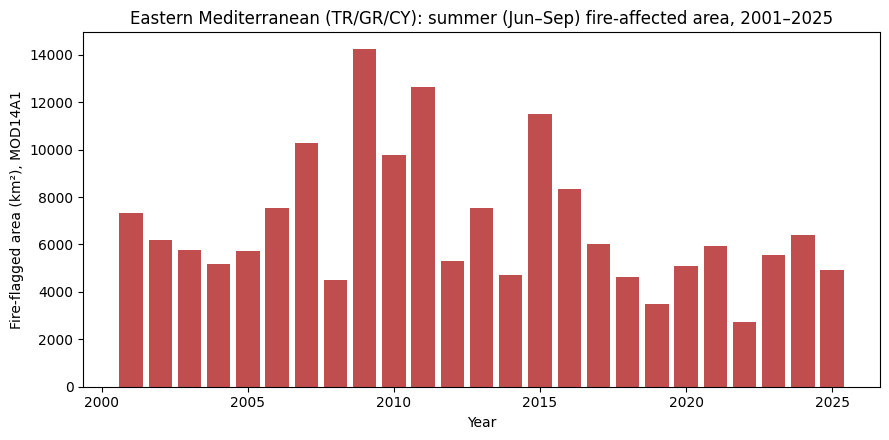

In [6]:
# --- Trend test on the annual summer burned-area series ---
x = df_trend["year"].values
y = df_trend["burned_area_km2"].values

if HAVE_MK:
    result = mk.original_test(y)
    print(f"Mann-Kendall trend: {result.trend}, p = {result.p:.4f}, Sen's slope = {result.slope:.2f} km2/yr")
else:
    slope, intercept, r, p, se = stats.linregress(x, y)
    print(f"Linear trend: slope = {slope:.2f} km2/yr, R2 = {r**2:.3f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df_trend["year"], df_trend["burned_area_km2"], color="firebrick", alpha=0.8)
ax.set_title("Eastern Mediterranean (TR/GR/CY): summer (Jun–Sep) fire-affected area, 2001–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Fire-flagged area (km²), MOD14A1")
plt.tight_layout()
plt.savefig("part1_trend_2001_2025.png", dpi=150)
plt.show()


## 2b. Cross-check with Aqua (MYD14A1) — sanity check for 2021

Terra's afternoon overpass time has drifted since ~2017 (documented MODIS orbit-drift issue), which can bias late-record fire counts downward and may explain why the very destructive 2021 Türkiye/Greece fire season doesn't stand out in the Terra series above. Aqua has a different overpass time and is less affected — re-running with `MYD14A1` is the fastest way to check whether the dip is a sensor artifact or a real signal.

In [7]:
def summer_fire_pixel_count_myd(year, aoi):
    """Same as summer_fire_pixel_count but using Aqua (MYD14A1) instead of Terra."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MYD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=aoi, scale=1000, maxPixels=1e10
    )
    return stats.get("FireMask")

check_years = [2018, 2019, 2020, 2021, 2022, 2023]
myd_records = []
for y in check_years:
    area_m2 = summer_fire_pixel_count_myd(y, aoi).getInfo()
    myd_records.append({"year": y, "aqua_burned_area_km2": (area_m2 or 0) / 1e6})

df_myd = pd.DataFrame(myd_records)
df_compare = df_myd.merge(
    df_trend[df_trend["year"].isin(check_years)].rename(columns={"burned_area_km2": "terra_burned_area_km2"}),
    on="year"
)
df_compare


,year,aqua_burned_area_km2,terra_burned_area_km2
0,2018,3861.778969,4644.483577
1,2019,3345.148291,3477.834740
2,2020,3355.004514,5089.706918
3,2021,5270.863813,5927.979522
4,2022,2036.761983,2733.136755
5,2023,3078.705318,5538.112452


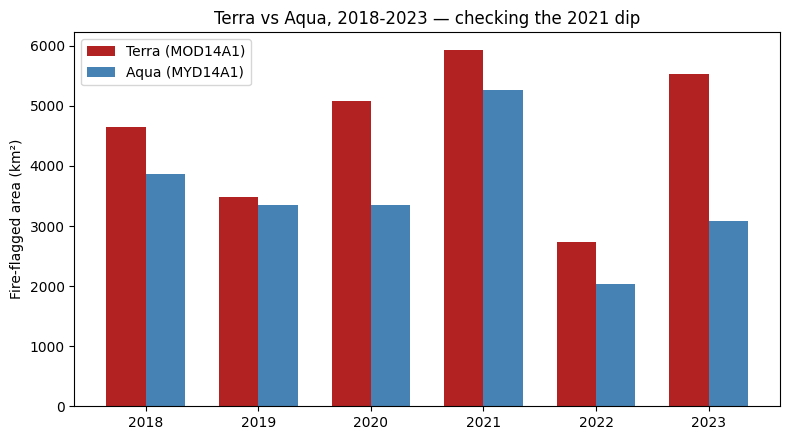

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.35
xpos = np.arange(len(df_compare))
ax.bar(xpos - width/2, df_compare["terra_burned_area_km2"], width, label="Terra (MOD14A1)", color="firebrick")
ax.bar(xpos + width/2, df_compare["aqua_burned_area_km2"], width, label="Aqua (MYD14A1)", color="steelblue")
ax.set_xticks(xpos)
ax.set_xticklabels(df_compare["year"])
ax.set_ylabel("Fire-flagged area (km²)")
ax.set_title("Terra vs Aqua, 2018-2023 — checking the 2021 dip")
ax.legend()
plt.tight_layout()
plt.savefig("part1_terra_vs_aqua_check.png", dpi=150)
plt.show()

# If Aqua also shows a 2021 dip, the low value is likely real (or a shared
# detection limitation, e.g. heavy smoke masking on the worst days).
# If Aqua shows a 2021 spike that Terra misses, this points to Terra's
# afternoon overpass drift as the culprit -- worth a footnote in the post
# either way, and a reason to prefer Aqua (or a Terra+Aqua blend) for the
# post-2017 portion of the trend line.


## 2c. Full-record Aqua series (2003–2025) and dual-sensor trend test

Aqua (MYD14A1) starts mid-2002, so 2003 is its first complete summer season. Running the same trend test on both sensors over their shared window tells us whether the Terra-based trend headline (peaks in 2009/2011/2015, lower plateau post-2018) is a real climatological signal or partly a Terra-specific artifact.

In [9]:
aqua_years = list(range(2003, 2026))
aqua_full_records = []
for y in aqua_years:
    area_m2 = summer_fire_pixel_count_myd(y, aoi).getInfo()
    aqua_full_records.append({"year": y, "aqua_burned_area_km2": (area_m2 or 0) / 1e6})

df_trend_aqua = pd.DataFrame(aqua_full_records)
df_trend_aqua.head()


,year,aqua_burned_area_km2
0,2003,5076.834931
1,2004,4707.652847
2,2005,4607.736526
3,2006,6424.192459
4,2007,9154.266906


In [10]:
# --- Trend test on the Aqua series, same window as available ---
xa = df_trend_aqua["year"].values
ya = df_trend_aqua["aqua_burned_area_km2"].values

if HAVE_MK:
    result_terra_shared = mk.original_test(
        df_trend[df_trend["year"].isin(aqua_years)]["burned_area_km2"].values
    )
    result_aqua = mk.original_test(ya)
    print(f"Terra (2003-2025 window): trend = {result_terra_shared.trend}, "
          f"p = {result_terra_shared.p:.4f}, Sen's slope = {result_terra_shared.slope:.2f} km2/yr")
    print(f"Aqua  (2003-2025):        trend = {result_aqua.trend}, "
          f"p = {result_aqua.p:.4f}, Sen's slope = {result_aqua.slope:.2f} km2/yr")
else:
    slope_t, _, r_t, p_t, _ = stats.linregress(
        xa, df_trend[df_trend["year"].isin(aqua_years)]["burned_area_km2"].values
    )
    slope_a, _, r_a, p_a, _ = stats.linregress(xa, ya)
    print(f"Terra (2003-2025 window): slope = {slope_t:.2f} km2/yr, R2 = {r_t**2:.3f}, p = {p_t:.4f}")
    print(f"Aqua  (2003-2025):        slope = {slope_a:.2f} km2/yr, R2 = {r_a**2:.3f}, p = {p_a:.4f}")

# Same conclusion from both sensors -> trend is robust to sensor choice.
# Different conclusion (e.g. only Terra shows a decline) -> the decline is
# at least partly a Terra orbit-drift artifact, not a real change in fire activity.


Terra (2003-2025 window): trend = no trend, p = 0.1538, Sen's slope = -112.14 km2/yr
Aqua  (2003-2025):        trend = decreasing, p = 0.0151, Sen's slope = -111.70 km2/yr


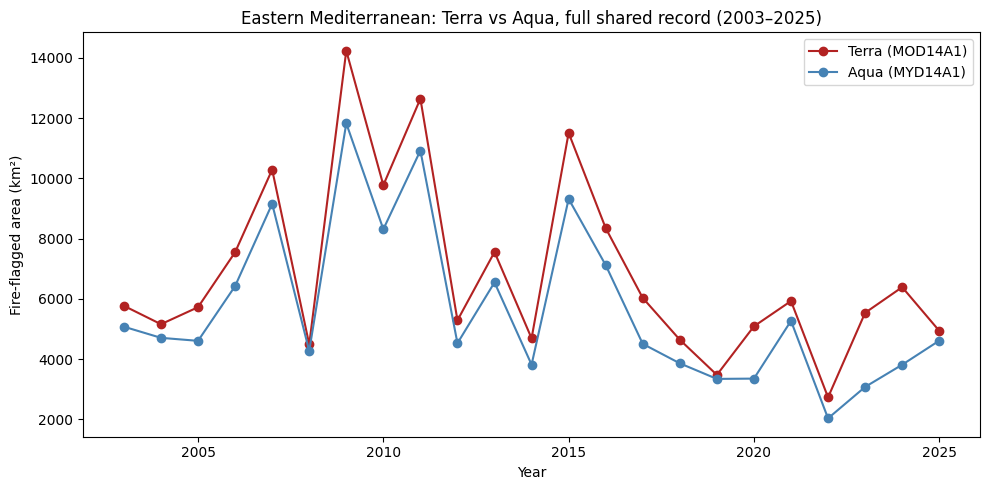

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df_terra_shared = df_trend[df_trend["year"].isin(aqua_years)]
ax.plot(df_terra_shared["year"], df_terra_shared["burned_area_km2"],
        marker="o", color="firebrick", label="Terra (MOD14A1)")
ax.plot(df_trend_aqua["year"], df_trend_aqua["aqua_burned_area_km2"],
        marker="o", color="steelblue", label="Aqua (MYD14A1)")
ax.set_title("Eastern Mediterranean: Terra vs Aqua, full shared record (2003–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Fire-flagged area (km²)")
ax.legend()
plt.tight_layout()
plt.savefig("part1_terra_vs_aqua_full_series.png", dpi=150)
plt.show()


## 3. Recent high-resolution detail — VIIRS 375 m (2023–2026)

Same logic, but with the finer VIIRS product for the seasons where it's available. This is the same data family behind the KCBD map that started this series, so it's a nice visual bridge for the blog post.

In [12]:
def viirs_summer_hotspot_count(year, aoi):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    snpp = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2").filterDate(start, end)
    noaa20 = ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2").filterDate(start, end)
    combined = snpp.merge(noaa20)
    detections = combined.select("Bright_ti4").map(lambda img: img.gt(0)).sum().gt(0)
    stats = detections.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=aoi, scale=375, maxPixels=1e10
    )
    return stats.get("Bright_ti4")

recent_years = [2024, 2025, 2026]
recent_records = []
for y in recent_years:
    area_m2 = viirs_summer_hotspot_count(y, aoi).getInfo()
    recent_records.append({"year": y, "hotspot_area_km2": (area_m2 or 0) / 1e6})

df_recent = pd.DataFrame(recent_records)
df_recent


,year,hotspot_area_km2
0,2024,19364.985042
1,2025,13419.041577
2,2026,5337.094482


In [13]:
# --- Current-season snapshot map (VIIRS, most recent 30 days available) ---
# ee.Date has no `.now()` -- build the window in Python and pass ISO strings instead.
import datetime
today = datetime.datetime.utcnow().date()
window_start = (today - datetime.timedelta(days=30)).isoformat()
window_end = today.isoformat()

latest = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2") \
    .merge(ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2")) \
    .filterDate(window_start, window_end) \
    .select("Bright_ti4").max()

vis = {"min": 280, "max": 400, "palette": ["yellow", "orange", "red", "darkred"]}
Map2 = geemap.Map()
Map2.centerObject(aoi, 5)
Map2.addLayer(aoi, {"color": "gray"}, "AOI outline", opacity=0.3)
Map2.addLayer(latest.clip(aoi), vis, "VIIRS hotspots, last 30 days")
Map2


Map(center=[39.15609550458322, 33.41495014918924], controls=(WidgetControl(options=['position', 'transparent_b…

## 4a. Climate context, baseline — ERA5-Land seasonal means (reference)

Kept as the naive baseline this section replaces. Seasonal (Jun–Sep) mean temperature and soil moisture, AOI-wide, correlated against fire area. **Result was weak and counter-intuitive** (r ≈ -0.22 for temperature, r ≈ 0.24 for soil moisture, both non-significant at n≈25) — averaging across a whole season and a climatically heterogeneous AOI (Aegean coast, Anatolian plateau, Taurus mountains) likely washes out the actual driver, which is probably short extreme-heat spells, not the seasonal mean.

In [14]:
def era5_summer_anomaly(year, aoi, band):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
             .filterDate(start, end)
             .select(band))
    mean_val = col.mean().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi, scale=10000, maxPixels=1e9
    )
    return mean_val.get(band)

climate_records = []
for y in years:
    t2m = era5_summer_anomaly(y, aoi, "temperature_2m").getInfo()
    sm = era5_summer_anomaly(y, aoi, "volumetric_soil_water_layer_1").getInfo()
    climate_records.append({
        "year": y,
        "mean_t2m_C": (t2m - 273.15) if t2m is not None else np.nan,
        "mean_soil_moisture": sm
    })

df_climate = pd.DataFrame(climate_records)
df_merged = df_trend.merge(df_climate, on="year")

r_temp, p_temp = stats.pearsonr(df_merged["mean_t2m_C"], df_merged["burned_area_km2"])
r_sm, p_sm = stats.pearsonr(df_merged["mean_soil_moisture"], df_merged["burned_area_km2"])
print(f"[baseline] Fire area vs mean summer T2m:    r = {r_temp:.2f}, p = {p_temp:.3f}")
print(f"[baseline] Fire area vs mean soil moisture: r = {r_sm:.2f}, p = {p_sm:.3f}")


[baseline] Fire area vs mean summer T2m:    r = -0.22, p = 0.284
[baseline] Fire area vs mean soil moisture: r = 0.24, p = 0.255


## 4b. Extreme-day metric, per country (primary analysis)

Hypothesis: fire area tracks the **number of extreme-heat days** (daily max T2m > 35°C) and **summer precipitation deficit**, not the seasonal mean — and this relationship should be more visible once Türkiye, Greece, and Cyprus are analyzed separately rather than pooled into one AOI-wide average.

⚠️ This section makes many `reduceRegion().getInfo()` calls (3 countries × ~25 years × 2 metrics) and will take a few minutes to run.

In [23]:
def region_area_km2(geom):
    """Total area of a geometry in km²."""
    return geom.area(maxError=1000).getInfo() / 1e6

# Hesapla ve bak — büyüklük farkını görmek için
for name, geom in country_geoms.items():
    print(f"{name}: {region_area_km2(geom):,.0f} km²")

Turkey: 779,833 km²
Greece: 131,774 km²
Cyprus: 9,059 km²


In [24]:
# --- Per-country geometries (reuse the LSIB features already filtered above) ---
country_geoms = {
    c: aoi_fc.filter(ee.Filter.eq("country_na", c)).geometry()
    for c in aoi_countries
}

def extreme_heat_days(year, geom, threshold_c=35):
    """Mean number of days (Jun-Sep) with daily max T2m above threshold_c, area-averaged."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("temperature_2m_max"))
    hot_day_count = col.map(lambda img: img.subtract(273.15).gt(threshold_c)).sum()
    val = hot_day_count.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("temperature_2m_max")

def summer_precip_total(year, geom):
    """Total Jun-Sep precipitation (m), area-averaged -- used to build a simple deficit index."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("total_precipitation_sum"))
    total_img = col.sum()
    val = total_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("total_precipitation_sum")


In [25]:
# --- Build per-country dataframe: fire area, heat days, precipitation ---
country_records = []
for c in aoi_countries:
    geom = country_geoms[c]
    for y in years:
        fire_m2 = summer_fire_pixel_count(y, geom).getInfo()
        heat_days = extreme_heat_days(y, geom).getInfo()
        precip = summer_precip_total(y, geom).getInfo()
        country_records.append({
            "country": c,
            "year": y,
            "fire_area_km2": (fire_m2 or 0) / 1e6,
            "extreme_heat_days": heat_days,
            "summer_precip_m": precip
        })

df_country = pd.DataFrame(country_records)

# Precipitation deficit as % departure from that country's own 2001-2025 mean
baseline_precip = df_country.groupby("country")["summer_precip_m"].transform("mean")
df_country["precip_anomaly_pct"] = (df_country["summer_precip_m"] - baseline_precip) / baseline_precip * 100

country_areas = {c: region_area_km2(country_geoms[c]) for c in aoi_countries}
df_country["region_area_km2"] = df_country["country"].map(country_areas)
df_country["fire_density_pct"] = df_country["fire_area_km2"] / df_country["region_area_km2"] * 100

df_country.head()


,country,year,fire_area_km2,extreme_heat_days,summer_precip_m,precip_anomaly_pct,region_area_km2,fire_density_pct
0,Turkey,2001,6010.175659,8.815223,0.081975,-27.702838,779833.320885,0.770700
1,Turkey,2002,5733.076280,5.658951,0.151467,33.585024,779833.320885,0.735167
2,Turkey,2003,5097.775352,7.015937,0.081732,-27.917471,779833.320885,0.653701
3,Turkey,2004,4375.632171,6.468854,0.092561,-18.366675,779833.320885,0.561098
4,Turkey,2005,5291.087834,7.510421,0.121899,7.507307,779833.320885,0.678490


In [26]:
# --- Per-country correlations: fire area vs extreme-heat days, vs precip deficit ---
print("Fire area vs extreme-heat days (per country):")
for c in aoi_countries:
    sub = df_country[df_country["country"] == c]
    r, p = stats.pearsonr(sub["extreme_heat_days"], sub["fire_area_km2"])
    print(f"  {c}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

print("\nFire area vs summer precipitation anomaly (per country):")
for c in aoi_countries:
    sub = df_country[df_country["country"] == c]
    r, p = stats.pearsonr(sub["precip_anomaly_pct"], sub["fire_area_km2"])
    print(f"  {c}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")


Fire area vs extreme-heat days (per country):
  Turkey: r = -0.25, p = 0.234, n = 25
  Greece: r = 0.56, p = 0.004, n = 25
  Cyprus: r = 0.31, p = 0.134, n = 25

Fire area vs summer precipitation anomaly (per country):
  Turkey: r = 0.22, p = 0.285, n = 25
  Greece: r = -0.22, p = 0.297, n = 25
  Cyprus: r = -0.52, p = 0.008, n = 25


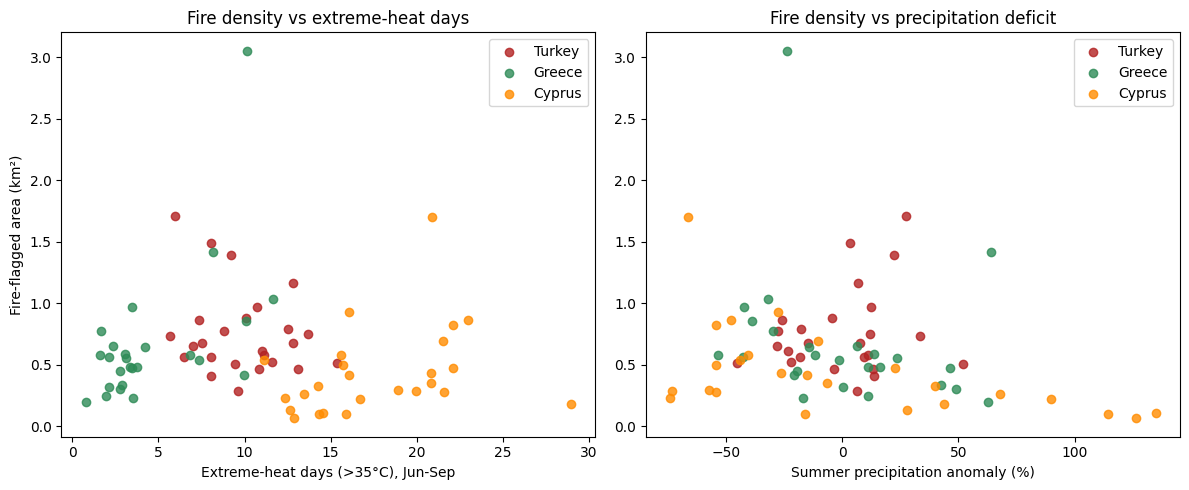

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Turkey": "firebrick", "Greece": "seagreen", "Cyprus": "darkorange"}

for c in aoi_countries:
    sub = df_country[df_country["country"] == c]
    axes[0].scatter(sub["extreme_heat_days"], sub["fire_density_pct"],
                     label=c, color=colors[c], alpha=0.8)
    axes[1].scatter(sub["precip_anomaly_pct"], sub["fire_density_pct"],
                     label=c, color=colors[c], alpha=0.8)

axes[0].set_xlabel("Extreme-heat days (>35°C), Jun-Sep")
axes[0].set_ylabel("Fire-flagged area (km²)")
axes[0].set_title("Fire density vs extreme-heat days")
axes[0].legend()

axes[1].set_xlabel("Summer precipitation anomaly (%)")
axes[1].set_title("Fire density vs precipitation deficit")
axes[1].legend()

plt.tight_layout()
plt.savefig("part1_extreme_days__density_per_country.png", dpi=150)
plt.show()

# Reminder: n~25 per country still limits statistical power. If the extreme-day
# and precip-deficit correlations come out clearly stronger than the pooled
# seasonal-mean baseline in 4a, that's the headline methodological finding for
# the post -- even if individual country correlations aren't significant on
# their own, a consistent sign and magnitude across all three countries is
# itself evidence for the extreme-event framing.


## 4c. Digging into the Turkey anomaly — coastal vs. interior split

Turkey was the one country where neither extreme-heat days nor precipitation deficit tracked fire area (both non-significant, and both wrong-signed). Two candidate explanations: (1) fires are driven more by ignition source (human-caused, power-line faults) than by seasonal climate, or (2) a country-wide average is too coarse — Turkey spans the Aegean/Mediterranean maquis belt *and* the much drier, more continental interior, and averaging them together could cancel out a real signal in either one. This section tests explanation (2) first, since it's the cheaper one to rule in or out.

Uses FAO GAUL level-1 provinces to split Turkey into a coastal Aegean/Mediterranean fire belt vs. everything else. **Check the printed province name list below before filtering** — GAUL naming/diacritics can be inconsistent (e.g. `Icel` vs `Mersin`), so confirm the exact strings that exist in the dataset rather than trusting the list as written here.

In [28]:
# --- List Turkey's GAUL level-1 province names so we can confirm exact spellings ---
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")
tr_provinces = gaul.filter(ee.Filter.eq("ADM0_NAME", "Turkey"))
province_names = tr_provinces.aggregate_array("ADM1_NAME").getInfo()
sorted(province_names)


['Adana',
 'Adiyaman',
 'Afyon',
 'Agri',
 'Aksaray',
 'Amasya',
 'Ankara',
 'Antalya',
 'Ardahan',
 'Artvin',
 'Aydin',
 'Balikesir',
 'Bartin',
 'Batman',
 'Bayburt',
 'Bilecik',
 'Bingol',
 'Bitlis',
 'Bolu',
 'Burdur',
 'Bursa',
 'Canakkale',
 'Cankiri',
 'Corum',
 'Denizli',
 'Diyarbakir',
 'Edirne',
 'Elazig',
 'Erzincan',
 'Erzurum',
 'Eskisehir',
 'Gaziantep',
 'Giresun',
 'Gumushane',
 'Hakkari',
 'Hatay',
 'Icel',
 'Igdir',
 'Isparta',
 'Istanbul',
 'Izmir',
 'K.maras',
 'Karabuk',
 'Karaman',
 'Kars',
 'Kastamonu',
 'Kayseri',
 'Kilis',
 'Kirikkale',
 'Kirklareli',
 'Kirsehir',
 'Kocaeli',
 'Konya',
 'Kutahya',
 'Malatya',
 'Manisa',
 'Mardin',
 'Mugla',
 'Mus',
 'Nevsehir',
 'Nigde',
 'Ordu',
 'Osmaniye',
 'Rize',
 'Sakarya',
 'Samsun',
 'Sanliurfa',
 'Siirt',
 'Sinop',
 'Sirnak',
 'Sivas',
 'Tekirdag',
 'Tokat',
 'Trabzon',
 'Tunceli',
 'Usak',
 'Van',
 'Yalova',
 'Yozgat',
 'Zonguldak']

In [29]:
# --- Define the coastal Aegean/Mediterranean fire belt (adjust list after checking spellings above) ---
coastal_fire_provinces = [
    "Canakkale", "Balikesir", "Izmir", "Aydin", "Mugla",
    "Antalya", "Mersin", "Adana", "Hatay"
]

coastal_fc = tr_provinces.filter(ee.Filter.inList("ADM1_NAME", coastal_fire_provinces))
coastal_geom = coastal_fc.geometry().dissolve()

turkey_geom = country_geoms["Turkey"]
interior_geom = turkey_geom.difference(coastal_geom, ee.ErrorMargin(1000))

Map3 = geemap.Map()
Map3.centerObject(turkey_geom, 6)
Map3.addLayer(interior_geom, {"color": "gray"}, "Interior/other")
Map3.addLayer(coastal_geom, {"color": "firebrick"}, "Coastal Aegean/Mediterranean belt")
Map3


Map(center=[39.13496301964721, 35.17514827319707], controls=(WidgetControl(options=['position', 'transparent_b…

In [30]:
# --- Re-run fire area + extreme-heat days + precip deficit for each Turkey sub-region ---
turkey_subregions = {"Turkey (coastal belt)": coastal_geom, "Turkey (interior/other)": interior_geom}

subregion_records = []
for label, geom in turkey_subregions.items():
    for y in years:
        fire_m2 = summer_fire_pixel_count(y, geom).getInfo()
        heat_days = extreme_heat_days(y, geom).getInfo()
        precip = summer_precip_total(y, geom).getInfo()
        subregion_records.append({
            "region": label, "year": y,
            "fire_area_km2": (fire_m2 or 0) / 1e6,
            "extreme_heat_days": heat_days,
            "summer_precip_m": precip
        })

df_tr_sub = pd.DataFrame(subregion_records)
baseline_p = df_tr_sub.groupby("region")["summer_precip_m"].transform("mean")
df_tr_sub["precip_anomaly_pct"] = (df_tr_sub["summer_precip_m"] - baseline_p) / baseline_p * 100
subregion_areas = {label: region_area_km2(geom) for label, geom in turkey_subregions.items()}
df_tr_sub["region_area_km2"] = df_tr_sub["region"].map(subregion_areas)
df_tr_sub["fire_density_pct"] = df_tr_sub["fire_area_km2"] / df_tr_sub["region_area_km2"] * 100
df_tr_sub.head()


,region,year,fire_area_km2,extreme_heat_days,summer_precip_m,precip_anomaly_pct,region_area_km2,fire_density_pct
0,Turkey (coastal belt),2001,1033.895991,9.846712,0.052246,-35.250785,97681.203684,1.058439
1,Turkey (coastal belt),2002,1352.676157,6.358178,0.116676,44.596434,97681.203684,1.384787
2,Turkey (coastal belt),2003,1936.897708,9.079479,0.045064,-44.151760,97681.203684,1.982877
3,Turkey (coastal belt),2004,1110.662136,7.900975,0.040692,-49.569786,97681.203684,1.137027
4,Turkey (coastal belt),2005,1608.189144,8.249529,0.075017,-7.030927,97681.203684,1.646365


Fire density vs extreme-heat days, by Turkey sub-region:
  Turkey (coastal belt): r = -0.04, p = 0.868, n = 25
  Turkey (interior/other): r = -0.21, p = 0.313, n = 25

Fire density vs precipitation anomaly, by Turkey sub-region:
  Turkey (coastal belt): r = -0.39, p = 0.052, n = 25
  Turkey (interior/other): r = 0.27, p = 0.193, n = 25


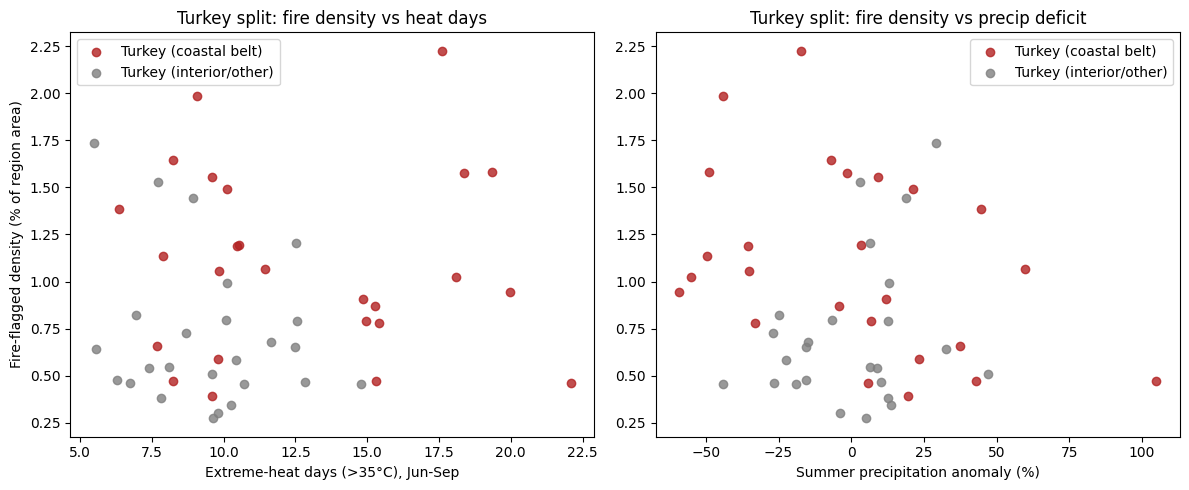

In [34]:
print("Fire density vs extreme-heat days, by Turkey sub-region:")
for label in turkey_subregions:
    sub = df_tr_sub[df_tr_sub["region"] == label]
    r, p = stats.pearsonr(sub["extreme_heat_days"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

print("\nFire density vs precipitation anomaly, by Turkey sub-region:")
for label in turkey_subregions:
    sub = df_tr_sub[df_tr_sub["region"] == label]
    r, p = stats.pearsonr(sub["precip_anomaly_pct"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub_colors = {"Turkey (coastal belt)": "firebrick", "Turkey (interior/other)": "gray"}
for label in turkey_subregions:
    sub = df_tr_sub[df_tr_sub["region"] == label]
    axes[0].scatter(sub["extreme_heat_days"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)
    axes[1].scatter(sub["precip_anomaly_pct"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)

axes[0].set_xlabel("Extreme-heat days (>35°C), Jun-Sep")
axes[0].set_ylabel("Fire-flagged density (% of region area)")
axes[0].set_title("Turkey split: fire density vs heat days")
axes[0].legend()

axes[1].set_xlabel("Summer precipitation anomaly (%)")
axes[1].set_title("Turkey split: fire density vs precip deficit")
axes[1].legend()

plt.tight_layout()
plt.savefig("part1_turkey_coastal_vs_interior_density.png", dpi=150)
plt.show()

# If the coastal belt alone now correlates with heat/precip the way Greece and
# Cyprus did, the country-wide average was indeed masking a real Mediterranean
# signal, and explanation (2) wins -- worth noting in the post that Turkey's
# fire ecology should be analyzed as (at least) two distinct regimes, not one.
# If neither sub-region correlates any better, that points back toward
# explanation (1): ignition source / human factors dominate over seasonal
# climate for Turkey specifically, which is itself a real and citable finding.


## 5. Notes for the write-up (fill in after running)

- [ ] Trend direction and significance (Mann-Kendall / linear) — headline number for the post.
- [ ] Terra vs Aqua: does the full 2003–2025 dual-sensor trend agree? If not,
  the post needs a methods footnote about Terra orbit drift rather than
  claiming a real decline post-2018.
- [ ] Where 2026's summer sits relative to 2024–2025 (VIIRS panel).
- [ ] Extreme-heat-day / precipitation-deficit correlations (4b) vs the
  seasonal-mean baseline (4a) — did per-country, extreme-event framing
  actually outperform the pooled seasonal mean? This ties into the FEoC
  forcing-side conversation with Chris (biomass-burning aerosol emissions
  scale with burned area, and burned area apparently tracks extremes better
  than seasonal averages).
- [ ] One clearly anomalous year to call out by name (2021 already confirmed
  as a genuine peak, not a data artifact — Section 2b/2c) as a sanity check
  that the pipeline is capturing real signal.
- [ ] Turkey coastal-belt vs. interior (4c): did splitting Turkey recover a
  climate signal the country-wide average was hiding, or does neither
  sub-region correlate — pointing toward ignition source / human factors as
  the dominant driver for Turkey specifically? Either answer is a real,
  citable finding for the post.

## 6. Next in the series

**Part 2 — Iberian Peninsula.** Same AOI-swap, same functions
(`summer_fire_pixel_count`, `summer_fire_pixel_count_myd`,
`viirs_summer_hotspot_count`, `extreme_heat_days`, `summer_precip_total`) —
only the country list and the narrative framing change. Worth refactoring
cells into a small `fireseries.py` module before Part 2 so both notebooks
import the same code instead of copy-pasting.
